# Loading a h5 dataset
- The h5-dataset is converted from the .mat structure to .h5 structure with "export_mat_to_h5.m" in "matlab_scripts" in this uxo-utils package
- it is modified from Lindsey's "plot_survey"-notebook

## It demonstrates
- Loading sensor details from BT '.yaml'-files.
- Loading a dataset from h5 into dictionary
- Loading a dataset from h5 into a more user-friendly Survey-structure
- Plotting coordinates of measurements (here, each time for the first receiver)
- Plotting time channel of the data according different approaches
    - Scatter
    - tricontourf (after Delaunay triangulation)
    - pclormesh

In [1]:
import numpy as np
import os
import h5py
import pandas as pd
from scipy.interpolate import griddata

import matplotlib.pyplot as plt
from matplotlib import cm as cmap
from matplotlib.colors import Normalize

import uxo_utils

/Users/u0102388/miniconda3/envs/UXO_M1/lib/python3.11/site-packages/BTSensor/BTSensor.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
sensorinfo = uxo_utils.load_sensor_info('UltraTEM')
ordnance = uxo_utils.load_ordnance_dict()

In [3]:
data_directory = '/Users/u0102388/Library/Mobile Documents/com~apple~CloudDocs/UBC-DATA/UXO_protected_Jan2020/data-blacktusk'
groundtruth = pd.read_excel(os.path.sep.join([data_directory, "groundtruth_Testplot5F.xlsx"]), nrows=93)

In [4]:
# Load h5-file in a dictionary - The "Raw" version
dfile = os.path.join(data_directory, 'Testplot5F.h5')
dic = uxo_utils.load_h5_data(dfile)

In [9]:
#Properties that can be extracted from the dataset
xyz_dict = dic["XYZ"]
xyz_dict['Info']['ChannelNames']


['Easting',
 'Northing',
 'Elevation',
 'GPSTime',
 'Fix',
 'PDOP',
 'Pitch',
 'Roll',
 'Yaw',
 'IMUAuxTm',
 'Index',
 'TxCur',
 'SurveyNum',
 'Fiducial',
 'Lines',
 'MeasNum',
 'RxNum',
 'Counter',
 'TxNum',
 'TxComp',
 'RxCNum',
 't154',
 't171',
 't190',
 't211',
 't235',
 't262',
 't292',
 't325',
 't361',
 't401',
 't446',
 't496',
 't551',
 't613',
 't681',
 't758',
 't842',
 't936',
 't1040',
 't1156',
 't1286',
 't1429',
 't1588',
 't1764',
 't1961',
 't2178',
 't2420',
 'tearly',
 'tmid',
 'tlate',
 'tearly_filterdist',
 'tmid_filterdist',
 'tlate_filterdist',
 't154_filterdist',
 't171_filterdist',
 't190_filterdist',
 't211_filterdist',
 't235_filterdist',
 't262_filterdist',
 't292_filterdist',
 't325_filterdist',
 't361_filterdist',
 't401_filterdist',
 't446_filterdist',
 't496_filterdist',
 't551_filterdist',
 't613_filterdist',
 't681_filterdist',
 't758_filterdist',
 't842_filterdist',
 't936_filterdist',
 't1040_filterdist',
 't1156_filterdist',
 't1286_filterdist',
 

In [10]:
index = 48 #Index here corresponds to "tearly"-channel

xyz_data = xyz_dict["Data"]
xyz_data[index, :].flatten()

array([ 107.8581875 ,  105.59357812,  354.70285156, ...,  118.93125561,
       -221.94881166,   11.30303812])

In [5]:
survey = uxo_utils.create_survey_from_file(dfile, True)

In [34]:
cm = plt.get_cmap('viridis')
c_norm = Normalize(vmin=survey.tmid.min(), vmax=survey.tmid.max())
scalar_map = cmap.ScalarMappable(norm=c_norm, cmap=cm)
scalar_map.set_array([])

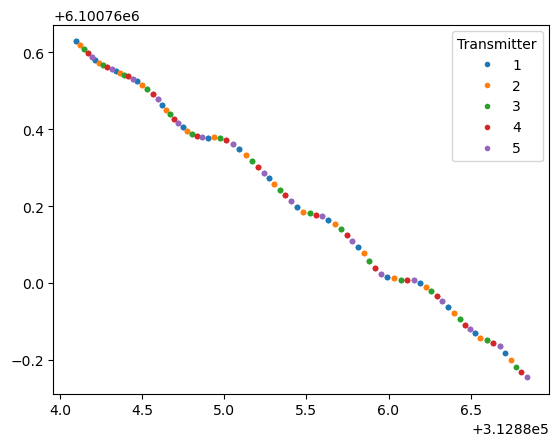

In [57]:
fig, ax = plt.subplots(1, 1)
line_inds = survey.line == 1013
for i in np.unique(survey.tx_num).astype(int):
    ii = line_inds & (survey.tx_num == i) & (survey.rx_num == 1)
    ax.plot(survey.easting[ii][:50], survey.northing[ii][:50], f'C{i}.', label=i+1)
ax.legend(title='Transmitter')
# ax.set_xlim([])

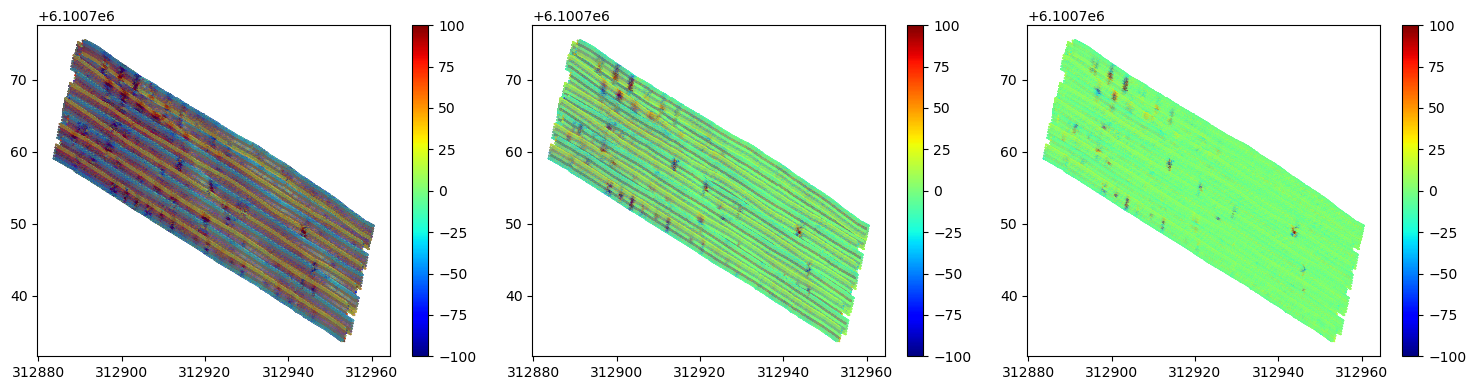

In [61]:
clim = 100*np.r_[-1, 1]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for a, tplot in zip(ax, [survey.tearly[::3], survey.tmid[::3], survey.tlate[::3]]):
    plt.colorbar(
        a.scatter(survey.easting[::3], survey.northing[::3], c=tplot, s=0.5, marker='.', cmap="jet", vmin=clim.min(), vmax=clim.max()),
        ax=a
    )

plt.tight_layout()

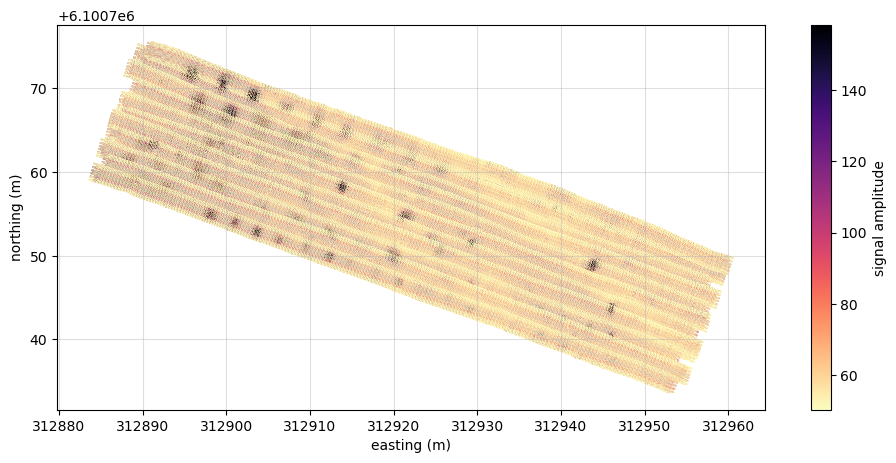

In [63]:
clim = 10**np.r_[1.7, 2.2]
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

cb = plt.colorbar(
    ax.scatter(survey.easting, survey.northing, c=np.abs(survey.tmid), s=0.25, marker='.', cmap="magma_r", vmin=clim.min(), vmax=clim.max(), alpha=1),
    ax=ax
)
ax.set_aspect(1)
ax.set_xlabel("easting (m)")
ax.set_ylabel("northing (m)")
cb.set_label("signal amplitude")
ax.grid(which="both", alpha=0.4)

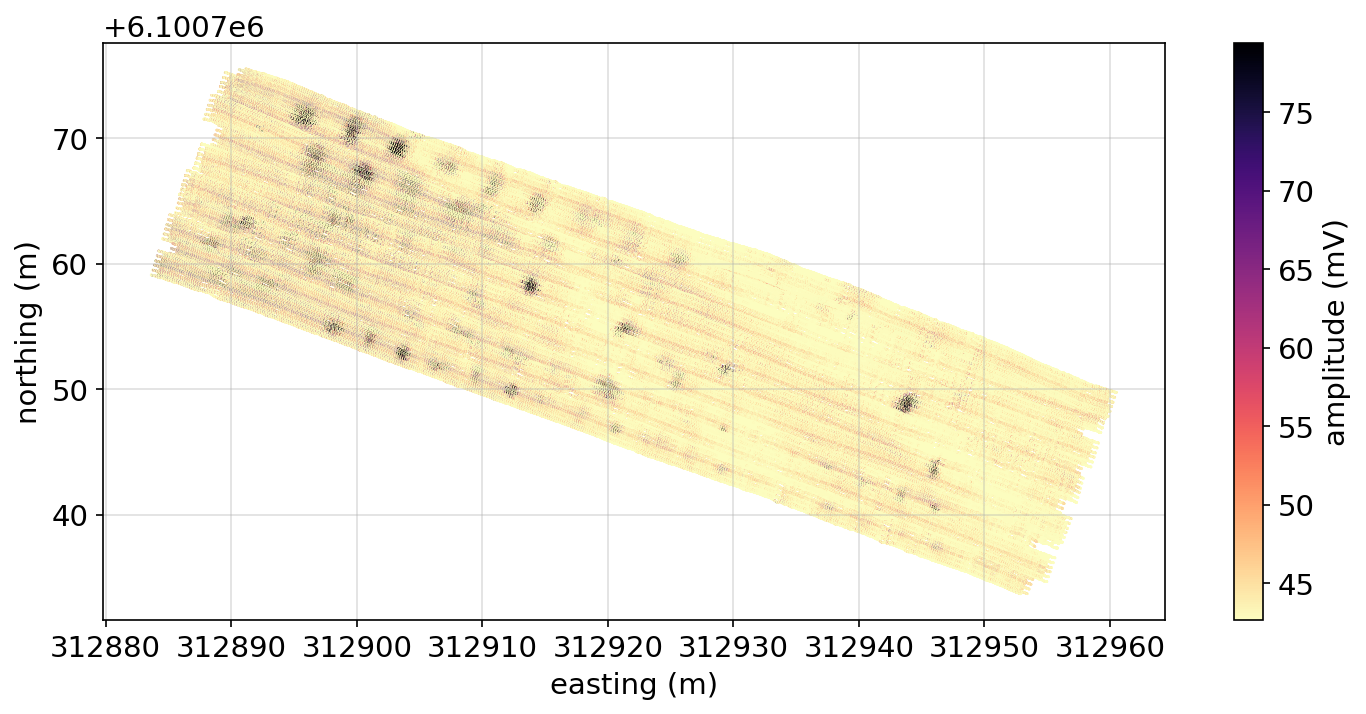

In [20]:
clim = 10**np.r_[1.63, 1.9]
fig, ax = plt.subplots(1, 1, figsize=(12, 5), dpi=150)

cb = plt.colorbar(
    ax.scatter(
        survey.easting, survey.northing, c=np.abs(survey.tlate), marker='.',
        cmap="magma_r", vmin=clim.min(), vmax=clim.max(), s=0.1
    ), 
    ax=ax
)
ax.set_aspect(1)
ax.set_xlabel("easting (m)")
ax.set_ylabel("northing (m)")
cb.set_label("amplitude (mV)")
ax.grid(which="both", alpha=0.4)

In [64]:
all_items = np.unique(groundtruth["ItemBuried"])
all_items

array(['20mm', 'EOD9115', 'EOD9145', 'EOD9146', 'EOD9147', 'EOD9148',
       'EOD9149', 'EOD9150', 'EOD9151', 'EOD9152', 'EOD9153', 'EOD9154',
       'EOD9156', 'EOD9157', 'EOD9160', 'East 5m', 'Large ISO',
       'Medium ISO', 'Native1', 'Native12', 'Native2', 'Native3',
       'Native4', 'Native5', 'Native8', 'North 5m', 'Railway',
       'Small ISO', 'South 5m', 'West 5m'], dtype=object)

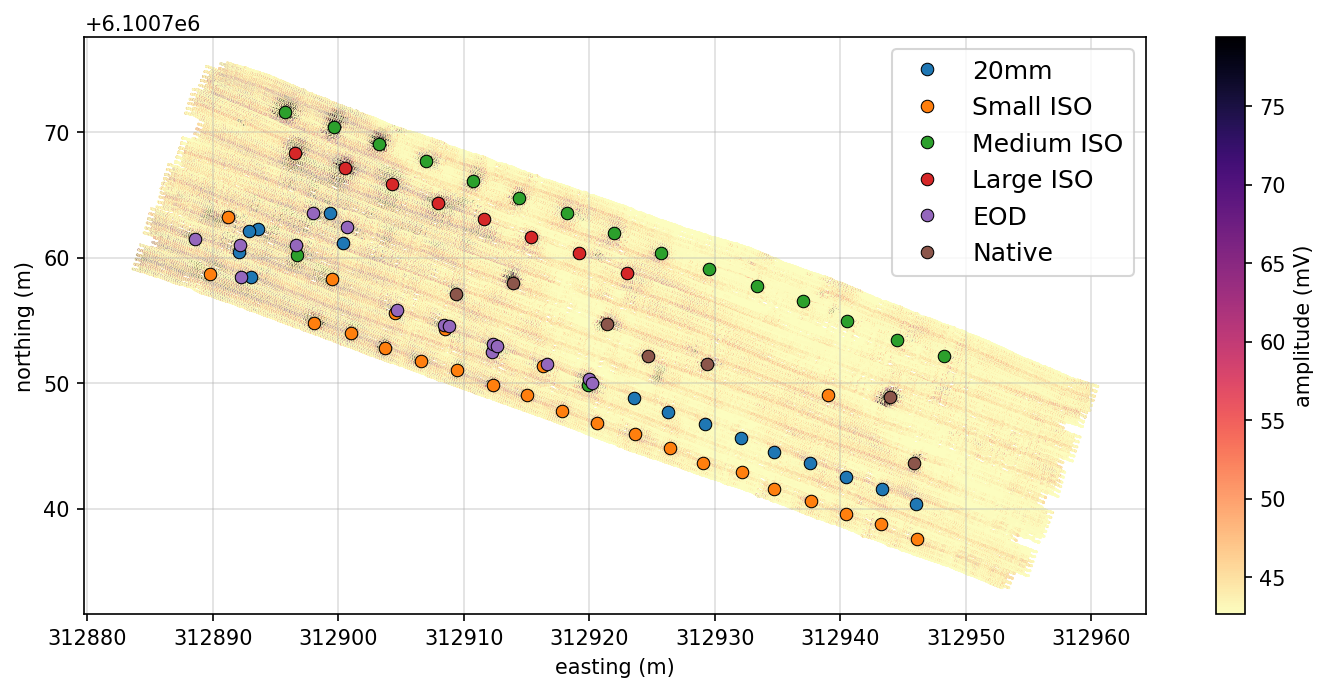

In [65]:
clim = 10**np.r_[1.63, 1.9]
fig, ax = plt.subplots(1, 1, figsize=(12, 5), dpi=150)

cb = plt.colorbar(
    ax.scatter(
        survey.easting, survey.northing, c=np.abs(survey.tlate), marker='.',
        cmap="magma_r", vmin=clim.min(), vmax=clim.max(), s=0.1
    ), 
    ax=ax
)

for i, item in enumerate(
    ["20mm", "Small ISO", "Medium ISO", "Large ISO", "EOD", "Native"]
):
    if item in ["EOD", "Native"]:
        inds = [j for j, itm in enumerate(groundtruth["ItemBuried"]) if itm.startswith(item)]
    else: 
        inds = groundtruth["ItemBuried"] == item
    plt.plot(
        groundtruth["Easting"][inds], groundtruth["Northing"][inds], f"C{i}o", 
        mec="k", mew="0.5", label=item
    )
ax.set_aspect(1)
ax.set_xlabel("easting (m)")
ax.set_ylabel("northing (m)")
cb.set_label("amplitude (mV)")
ax.grid(which="both", alpha=0.4)
ax.legend(fontsize=12)

0.0

'for i, item in enumerate(synthetic_subset["item"]):\n    if item == "Small ISO":\n        ax.plot(synthetic_subset["easting"][i], synthetic_subset["northing"][i], \'C0o\', ms=8, mec="w")\n    elif item == "Medium ISO":\n        ax.plot(synthetic_subset["easting"][i], synthetic_subset["northing"][i], \'C2s\', ms=8, mec="w")\n    elif item == "Large ISO":\n        ax.plot(synthetic_subset["easting"][i], synthetic_subset["northing"][i], \'C5v\', ms=8, mec="w")\n    elif item == "20mm":\n        ax.plot(synthetic_subset["easting"][i], synthetic_subset["northing"][i], \'C6d\', ms=8, mec="w")'

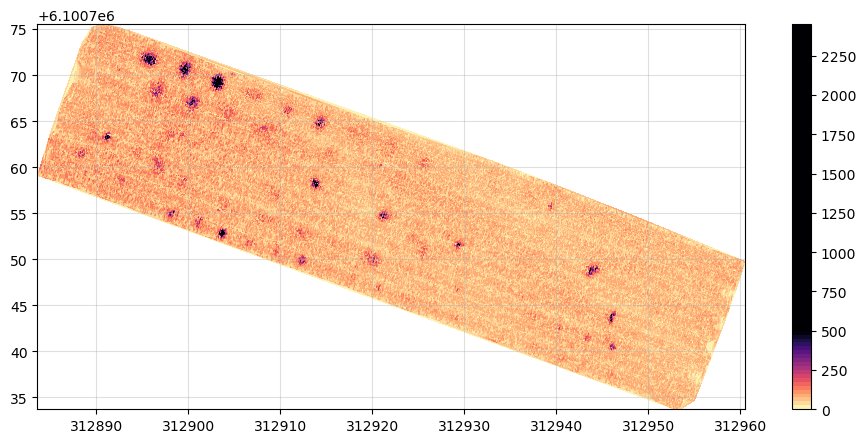

In [95]:
clim = np.r_[0, 500]


from scipy.spatial import Delaunay
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

# Create triangulation.
tri = Delaunay(np.hstack([survey.easting[:, None], survey.northing[:, None]]))

cb = plt.colorbar(ax.tricontourf(
    tri.points[:, 0], tri.points[:, 1],
    np.abs(survey.tmid[:]), levels=100,
    cmap="magma_r", vmin=clim.min(), vmax=clim.max()
    ), 
    ax=ax,
)
# cb.set_clim([0.3, 1])

ax.set_aspect(1)
ax.grid(which="both", alpha=0.4)

"""for i, item in enumerate(synthetic_subset["item"]):
    if item == "Small ISO":
        ax.plot(synthetic_subset["easting"][i], synthetic_subset["northing"][i], 'C0o', ms=8, mec="w")
    elif item == "Medium ISO":
        ax.plot(synthetic_subset["easting"][i], synthetic_subset["northing"][i], 'C2s', ms=8, mec="w")
    elif item == "Large ISO":
        ax.plot(synthetic_subset["easting"][i], synthetic_subset["northing"][i], 'C5v', ms=8, mec="w")
    elif item == "20mm":
        ax.plot(synthetic_subset["easting"][i], synthetic_subset["northing"][i], 'C6d', ms=8, mec="w")"""

# rotate data

In [96]:
# rotate data
from scipy import stats
# local coordinates for the data set 
x0, y0 = np.mean(survey.easting), np.mean(survey.northing)
local_easting = survey.easting - x0
local_northing = survey.northing - y0

slope, intercept, _, _, _ = stats.linregress(local_easting, local_northing)
print(slope, intercept)

-0.3486944749895929 6.346738382583071e-10


In [97]:
theta = np.arctan(slope)+np.pi/2
local_x = np.cos(theta) * local_easting + np.sin(theta) * local_northing
local_y = -np.sin(theta) * local_easting + np.cos(theta) * local_northing

local_ground_truth_easting = np.array(groundtruth["Easting"] - x0)
local_ground_truth_northing = np.array(groundtruth["Northing"] - y0)
local_ground_truth_x = np.cos(theta) * local_ground_truth_easting + np.sin(theta) * local_ground_truth_northing
local_ground_truth_y = -np.sin(theta) * local_ground_truth_easting + np.cos(theta) * local_ground_truth_northing

In [98]:
nx = 50
ny = 500
gridded_x = np.linspace(local_x.min(), local_x.max(), nx)
gridded_y = np.linspace(local_y.min(), local_y.max(), ny)

XY = np.meshgrid(gridded_x, gridded_y)

In [99]:
XY[0].shape

(500, 50)

In [100]:
gridded_t_early = griddata(np.vstack([local_x, local_y]).T, survey.tearly, tuple(XY), 'cubic')
gridded_t_mid = griddata(np.vstack([local_x, local_y]).T, survey.tmid, tuple(XY), 'cubic')
gridded_t_late = griddata(np.vstack([local_x, local_y]).T, survey.tlate, tuple(XY), 'cubic')

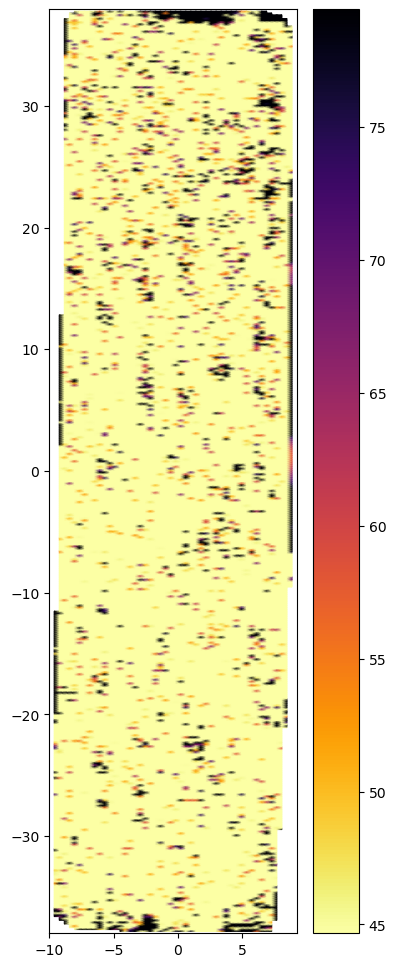

In [101]:
fig, ax = plt.subplots(1, 1, figsize=(4, 12))
clim = 10**np.r_[1.65, 1.9]
plt.colorbar(
    plt.pcolormesh(
        gridded_x, gridded_y, np.abs(gridded_t_late), vmin=clim.min(), vmax=clim.max(), shading="gouraud",
        cmap="inferno_r",
    )
)